# MVP — Machine Learning & Analytics

**Nome:** _André Vital de Medeiros_  
**Matrícula:** _4052025000626_  
**Data:** _05/07/2026_  
**Dataset:** _[Dados de produção do anuário estatístico da ANP (Agência Nacional do Petróleo, Gás Natural e Biocombustíveis) já tratados na Sprint de Análise de Dados e Boas Práticas](https://github.com/andrevital001/PUC_MVP_2/blob/main/Dataset%20-%20MVP%20II%20-%20Machine%20Learning%20e%20Analytics.csv)_  
**Tipo de problema:** _Regressão_

# 1. Definição do problema

## 1.1 Descrição do problema

A ANP (Agência Nacional do Petróleo, Gás Natural e Biocombustíveis)disponibiliza os dados anuais de produção, subdividindo esses dados em categorias, como: **Tipo de Produto**, **Unidade Federativa** e **Unidade de Medida**.

Foi acrescentada à base original, a informação de Tipo de Combustível (Fóssil ou Renovável), a fim de agregar uma categoria que julgo ter impacto nas variações apresentadas na série temporal.  Algumas outras informações fazem parte do relatório da ANP, porém apenas essas categorias citadas anteriormente, associadas a informação do volume produzido, serão utilizadas neste problema.

Entendemos que a resposta desta análise é de grande importância para a Federeção, assim como para a indústria petrolífera nacional e internacional.

## 1.2 Objetivo do MVP

> Observando as variações dos dados presentes neste dataset e a importância da compreensão dos dados apresentados, assim como a projeção futura dos dados de produção, temos como objetivo **construir modelos capazes de aprender os padrões históricos da produção energética brasileira e gerar projeções para os anos subsequentes**.


## 1.3 Tipo de problema


**Tipo escolhido:** _Regressão supervisionada_  


**Justificativa:**

_Este trabalho caracteriza-se como um problema de aprendizado supervisionado do tipo regressão, com objetivo de prever valores numéricos contínuos referentes à produção energética brasileira a partir de dados históricos._

_O estudo busca identificar padrões presentes nos dados históricos de produção energética entre 2014 e 2023 e avaliar a capacidade de diferentes algoritmos de Machine Learning em estimar a variável alvo. Para isso, foram comparados modelos de regressão supervisionada, utilizando métricas quantitativas de desempenho para selecionar a abordagem mais adequada ao problema proposto._


## 1.4 Premissas, hipóteses e critérios de sucesso

**Premissas:**

* Entende-se que os registros históricos compreendidos entre 2014 e 2023 contêm padrões capazes de auxiliar na estimativa da produção futura.

* As variáveis selecionadas (Ano, Unidade Federativa, Produto, Região e Tipo de Energia) possuem relação com a fllutuação dos volumes de produção.


* Não serão considerados fatores externos não presentes no dataset, como crises econômicas, alterações regulatórias, conflitos geopolíticos, avanços tecnológicos ou mudanças significativas na política energética nacional.
Hipóteses



---


**Hipóteses:**

* Modelos de Machine Learning são capazes de aprender os padrões históricos existentes na base de dados e produzir estimativas razoavelmente precisas da produção energética.

* Modelos não lineares baseados em árvores de decisão, como Random Forest e Gradient Boosting, apresentarão desempenho superior ao modelo de Regressão Linear, devido à sua maior capacidade de capturar relações complexas entre as variáveis.

* A inclusão de atributos derivados, como Região e Tipo de Energia (Fóssil ou Renovável), contribuirá para melhorar a capacidade preditiva dos modelos.

* Os padrões observados para combustíveis renováveis e fósseis poderão apresentar comportamentos distintos ao longo do horizonte de projeção.



---


**Critérios de Sucesso:**

O MVP será considerado bem-sucedido caso:

* Seja capaz de treinar e avaliar modelos de regressão utilizando os dados históricos de produção energética.
* Permita comparar diferentes algoritmos de Machine Learning por meio dos frameworks adequados para regressão.
* Alcance desempenho satisfatório em dados não utilizados durante o treinamento, demonstrando capacidade de generalização.
* Identifique o modelo com melhor desempenho entre os algoritmos avaliados.
* Gere informações que possam auxiliar análises estratégicas relacionadas ao comportamento futuro da matriz energética brasileira.

# 2. Ambiente, bibliotecas e reprodutibilidade

Esta seção deve reunir as importações, configuração de seed e informações básicas do ambiente.

**O que incluir:**
- bibliotecas utilizadas;
- seed fixa para reprodutibilidade;
- observações sobre GPU/CPU, quando relevante;
- versões de bibliotecas, se houver dependências específicas.


In [42]:
# === Setup básico e reprodutibilidade ===
import os
import sys
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import TimeSeriesSplit

from sklearn.metrics import (
mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed:", SEED)


Python: 3.12.13
Seed: 42


## 2.1 Funções auxiliares

Use funções para evitar repetição e deixar o notebook mais organizado.

> **Comentário:** não é obrigatório criar classes. Em notebooks de ML, funções bem nomeadas geralmente já melhoram bastante a legibilidade.


In [44]:
# Treina um Pipeline contendo o pré-processamento e o modelo informado, calcula as métricas e retorna os resultados.

def avaliar_modelo(nome_modelo, modelo, X_train, X_test, y_train, y_test):

    pipeline = Pipeline(
        steps=[
            ("preprocessamento", preprocessor),
            ("modelo", modelo)
        ]
    )

    pipeline.fit(X_train, y_train)

    y_pred_log = pipeline.predict(X_test)

    # Retorna para escala original
    y_pred = np.expm1(y_pred_log)
    y_real = np.expm1(y_test)

    mae = mean_absolute_error(y_real, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_real, y_pred)
    )

    r2 = r2_score(y_real, y_pred)

    resultados = {
        "Modelo": nome_modelo,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    }

    return pipeline, resultados

# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

A origem dos dados do dataset escolhido é o **Anuário Estatístico Brasileiro do Petróleo, Gás Natural e Biocombustíveis**, disponibilizado no [portal do governo](https://www.gov.br/anp/pt-br/centrais-de-conteudo/publicacoes/anuario-estatistico/anuario-estatistico-brasileiro-do-petroleo-gas-natural-e-biocombustiveis-2025), pela ANP.

Os dados deste portal são públicos.

Foram selecionados as seguintes tabelas presentes neste anuário:

* Tabela 2.9 - Produção de petróleo, por localização (terra e mar, pré-sal e pós-sal), segundo unidades da Federação - 2014-2023

* Tabela 2.10 - Produçao de LGN, segundo unidades da Federaçao - 2014-2023

* Tabela 2.13 - Produção de gás natural, por localização (terra e mar, pré-sal e pós-sal), segundo unidades da Federação - 2014-2023

* Tabela 4.1 - Producao de etanol anidro e hidratado, segundo grandes regioes e unidades da Federaçao - 2014-2023

* Tabela 4.10 - Produção de biodiesel (B100), segundo grandes regiões e unidades da Federação - 2014-2023

* Tabela 4.17 - Producao de biometano, segundo grandes regiões e unidades da Federacao - 2020-2023

Os dados passaram pelo pré-tratamento no MVP da Sprint de Análise de Dados e Boas Prática, já entregue e aprovado. Logo, neste MPV será utilizado o [dataset já tratado](https://github.com/andrevital001/PUC_MVP_2/blob/main/Dataset%20-%20MVP%20II%20-%20Machine%20Learning%20e%20Analytics.csv).


## 3.2 Carga dos dados

In [46]:
url = "https://raw.githubusercontent.com/andrevital001/PUC_MVP_2/main/Dataset%20-%20MVP%20II%20-%20Machine%20Learning%20e%20Analytics.csv"
df = pd.read_csv(url)

df.head()

,index,Unidades da Federacao,Unidade,Produto,Ano,Producao,Tipo
0,0,Acre,(mil m3),Etanol anidro e hidratado,2014,0,Renovável
1,1,Alagoas,(mil barris),LGN,2014,51600,Fóssil
2,2,Alagoas,(mil barris),Petroleo,2014,26690,Fóssil
3,3,Alagoas,(mil m3),Etanol anidro e hidratado,2014,48525,Renovável
4,4,Alagoas,(milhoes de m3),Gas Natural,2014,5353,Fóssil


## 3.3 Visão geral do dataset


### **Visão geral da base**

> O dataset carregado possui 720 linhas e 7 colunas.

> A variável alvo a ser utilizada é apresentada na coluna 'Producao'.

### **Colunas a serem desconsideradas no dataset**

> Entende-se que as colunas 'index' e 'Unidade' poderão ser desconsideradas, pois não contribuem para a execução dos modelos.

> Diferente das demais colunas presentes no dataset, estas não apresentam impacto na flutuação da variável alvo.

In [47]:
# Remover colunas 'index' e 'Unidade'
df = df.drop(columns=["index", "Unidade"])

df.head()

,Unidades da Federacao,Produto,Ano,Producao,Tipo
0,Acre,Etanol anidro e hidratado,2014,0,Renovável
1,Alagoas,LGN,2014,51600,Fóssil
2,Alagoas,Petroleo,2014,26690,Fóssil
3,Alagoas,Etanol anidro e hidratado,2014,48525,Renovável
4,Alagoas,Gas Natural,2014,5353,Fóssil



### **Colunas a serem acrescentadas para aprimoramento do modelo**

> Diante da presença de grande parte das Unidades Federativas e diferentes ênfases de investimento em cada uma delas, foi adicionada ao dataframe a coluna 'Regiao' pois acredita-se que este agrupamento pode contribuir com informações adicionais para análise do modelo.

In [48]:
# Adicionar coluna 'Regiao'

uf_regiao = {
    'Acre': 'Norte',
    'Alagoas': 'Nordeste',
    'Amazonas': 'Norte',
    'Bahia': 'Nordeste',
    'Ceara': 'Nordeste',
    'Distrito Federal': 'Centro-Oeste',
    'Espirito Santo': 'Sudeste',
    'Goias': 'Centro-Oeste',
    'Maranhao': 'Nordeste',
    'Mato Grosso': 'Centro-Oeste',
    'Mato Grosso do Sul': 'Centro-Oeste',
    'Minas Gerais': 'Sudeste',
    'Para': 'Norte',
    'Paraiba': 'Nordeste',
    'Parana': 'Sul',
    'Pernambuco': 'Nordeste',
    'Piaui': 'Nordeste',
    'Rio Grande do Norte': 'Nordeste',
    'Rio Grande do Sul': 'Sul',
    'Rio de Janeiro': 'Sudeste',
    'Rondonia': 'Norte',
    'Santa Catarina': 'Sul',
    'Sao Paulo': 'Sudeste',
    'Sergipe': 'Nordeste',
    'Tocantins': 'Norte'
}


df['Regiao'] = df['Unidades da Federacao'].map(uf_regiao)

df.head()

,Unidades da Federacao,Produto,Ano,Producao,Tipo,Regiao
0,Acre,Etanol anidro e hidratado,2014,0,Renovável,Norte
1,Alagoas,LGN,2014,51600,Fóssil,Nordeste
2,Alagoas,Petroleo,2014,26690,Fóssil,Nordeste
3,Alagoas,Etanol anidro e hidratado,2014,48525,Renovável,Nordeste
4,Alagoas,Gas Natural,2014,5353,Fóssil,Nordeste


In [49]:
print("Formato do dataset:", df.shape)
print("\nTipos de dados:")
display(df.dtypes.to_frame("tipo"))

Formato do dataset: (720, 6)

Tipos de dados:


,tipo
Unidades da Federacao,object
Produto,object
Ano,int64
Producao,int64
Tipo,object
Regiao,object


In [50]:
print("\nValores ausentes por coluna:")
display(df.isna().sum().to_frame("ausentes"))


Valores ausentes por coluna:


,ausentes
Unidades da Federacao,0
Produto,0
Ano,0
Producao,0
Tipo,0
Regiao,0


In [51]:
print("\nDuplicatas:", df.duplicated().sum())



Duplicatas: 0


In [52]:
display(df.sample(5, random_state=SEED))

,Unidades da Federacao,Produto,Ano,Producao,Tipo,Regiao
340,Rio de Janeiro,Biometano,2018,0,Renovável,Sudeste
290,Alagoas,Petroleo,2018,97200,Fóssil,Nordeste
54,Rio de Janeiro,Petroleo,2014,5632320,Fóssil,Sudeste
198,Rio de Janeiro,Petroleo,2016,6147130,Fóssil,Sudeste
453,Espirito Santo,Petroleo,2020,904000,Fóssil,Sudeste


## 3.4 Dicionário de dados

Preencha a tabela abaixo com os principais atributos.

| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
|---|---|---|---|---|
| index | numérica | _ID da linha_ | não | _Irrelevante para o objetivo proposto_ |
| Unidades da Federacao | categórica | _Estados_ | sim | _Rótulo de localidade dos volumes produzidos_ |
| Unidade | categórica | _Unidade de medida utilizada para variável alvo_ | não | _Esta informação não auxiliará o modelo em nossa análise_ |
| Produto | categórica | _Produto do refino a ser analisado_ | sim | _principal classificador da variável categórica_ |
| Ano | data | _Data de referência da produção_ | sim | _Marco de data para a construção da série temporal_ |
| Tipo | categórica | _Descriçãod o tipo de combustível produzido_ | sim | _Importante rótulo como classificador binário do produto_ |
| Producao | Alvo | _Informação do volume produzido_ | sim | _Variárvel alvo_ |
| Regiao | categórica | _Região Federativa referente ao Estado_ | sim | _Agrupamento da coluna Estado para uma análise menos abrangente considerando o fator geográfico_ |

# 4. Análise exploratória dos dados

### **Preparação da coluna 'Producao'**

> Os valores da coluna 'Producao' apresentaram grande assimetria, com média significativamente superior à mediana e valores máximos muito distantes da maior parte das observações. Para reduzir a influência de valores extremos e tornar a distribuição mais adequada ao processo de aprendizado, foi aplicada a transformação logarítmica utilizando a função log1p, que também permite tratar observações com valor zero.

In [53]:
# Análise dos valores presentes na coluna 'Producao' do dataset orginal

df["Producao"].describe()

,Producao
count,7.200000e+02
mean,4.137608e+06
std,3.073960e+07
min,0.000000e+00
25%,3.733500e+03
50%,3.434450e+04
75%,3.310585e+05
max,4.261009e+08


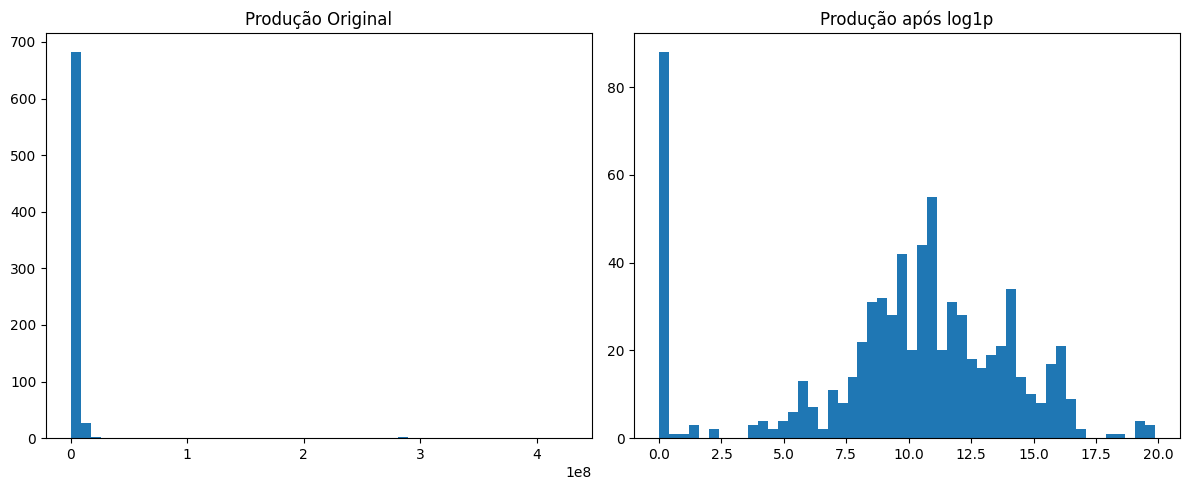

In [54]:
# Representação visual dos valores originais e após a transformação logarítimica


plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(df["Producao"], bins=50)
plt.title("Produção Original")

plt.subplot(1,2,2)
plt.hist(np.log1p(df["Producao"]), bins=50)
plt.title("Produção após log1p")

plt.tight_layout()
plt.show()

In [55]:
# A variável alvo foi transformada utilizando a função log1p(),
# mantendo-se a base original inalterada para fins de interpretação
# e comparação dos resultados.

y = np.log1p(df["Producao"])

y.describe()

,Producao
count,720.000000
mean,9.663249
std,4.644417
min,0.000000
25%,8.225346
50%,10.444192
75%,12.709768
max,19.870187


In [56]:
df["Produto"].value_counts()

,count
Produto,
Etanol anidro e hidratado,230
Biodiesel,160
Gas Natural,110
Petroleo,100
LGN,90
Biometano,30


In [57]:
TARGET = "Producao"
PROBLEM_TYPE = "regressao"

if TARGET is not None and TARGET in df.columns:
    print("Distribuição do target:")
    display(df[TARGET].value_counts(dropna=False).to_frame("contagem"))
    display((df[TARGET].value_counts(normalize=True, dropna=False) * 100).round(2).to_frame("percentual"))


Distribuição do target:


,contagem
Producao,
0,88
3,3
485,2
6740,2
2449,2
...,...
9065,1
40216,1
7165700,1


,percentual
Producao,
0,12.22
3,0.42
485,0.28
6740,0.28
2449,0.28
...,...
9065,0.14
40216,0.14
7165700,0.14


## 4.1 Síntese da análise exploratória

**Síntese:**  

> A base de dados utilizada neste estudo reúne informações sobre a produção energética brasileira entre os anos de 2014 e 2023, contemplando diferentes produtos energéticos e unidades federativas. Verificou-se que o conjunto de dados possui 720 registros e não apresenta valores ausentes, dispensando a necessidade de preenchimento de dados ou adoção de métodos de estimativa de dados.

> As variáveis disponíveis incluem informações sobre unidade federativa, produto energético, ano de referência, produção, tipo de energia (fóssil ou renovável) e região geográfica. Durante a análise, identificou-se que a coluna de **unidade de medida apresentava relação direta com o produto energético, não agregando informação adicional relevante para a modelagem.** Por esse motivo, essa variável foi removida das etapas posteriores.

> A análise da variável alvo revelou elevada dispersão e forte assimetria positiva. A média observada foi significativamente superior à mediana, indicando a presença de valores extremos e grande diferença de magnitude entre os produtos analisados. Essa característica também foi evidenciada pela existência de valores máximos muito superiores à maior parte das observações.

> Como consequência da elevada assimetria, optou-se pela **aplicação da transformação logarítmica utilizando a função** `log1p()`, reduzindo o impacto de valores extremos e tornando a distribuição mais adequada para o treinamento dos modelos de Machine Learning.

> Observou-se ainda que alguns produtos apresentavam registros de produção igual a zero, especialmente Biodiesel, Biometano e Etanol, refletindo períodos ou localidades sem produção registrada. **Entretanto, a quantidade desses registros não foi considerada suficiente para justificar sua remoção**.

> A distribuição dos registros por produto mostrou-se desigual, com maior representatividade do Etanol Anidro e Hidratado e menor quantidade de observações para o Biometano. **Apesar desse desbalanceamento, o comportamento é compatível com a realidade da produção energética brasileira e não compromete a utilização dos dados em um problema de regressão.**

# 5. Preparação dos dados e divisão treino/teste


Estruturação do pipeline a fim de evitar data leakage.

In [58]:
# Definição de features

features = [
    "Ano",
    "Unidades da Federacao",
    "Produto",
    "Tipo"
]

# Definição de target

target = "Producao"

y = np.log1p(df[target])

X = df[features]

## 5.1 Justificativa da divisão

Para divisão da base em treino/teste utilizaremos os dados de 2014 a 2021 para treino.

Os dados de 2022 e 2023 serão separados para teste.

> Considerando que o objetivo é a construção de um modelo que realize uma previsão para os próximos anos, os últimos anos da série foram selecionados para serem utilizados como teste.


In [59]:
# Separação

X_train = X[X["Ano"] <= 2021]
X_test  = X[X["Ano"] >= 2022]

y_train = y[X["Ano"] <= 2021]
y_test  = y[X["Ano"] >= 2022]

# Verificação

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)



Treino: (576, 4)
Teste: (144, 4)


# 6. Pré-processamento e pipeline

> As variáveis serão separadas por tipo, com objetivo de separarmos as váriáveis numéricas e as variáveis categóricas. Deste modo, transformamos as variáveis categóricas utilizando o One-Hot Encoding.

In [60]:
# Definição de variáveis categóricas

categoricas = [
    "Unidades da Federacao",
    "Produto",
    "Tipo"
]

# Definição de variáveis numéricas

numericas = [
    "Ano"
]

# Aplicação de tratamentos diferentes para cada grupo de colunas utilizando ColumnTransformer.

preprocessor = ColumnTransformer(
    transformers=[
        (
            # Obtém colunas categóricas, aplica OneHotEncoder e retona o resultado transformado
            "cat",

            # O parâmetro handle_unknown="ignore" permite que o pipeline siga funcionando ainda que apareçam novas variáveis categóricas
            OneHotEncoder(handle_unknown="ignore"),
            categoricas
        ),
        (
            # Mantém colunas numéricas, conforme dataset original
            "num",
            "passthrough",
            numericas
        )
    ]
)

# 7. Baseline e modelos candidatos

> Com objetivo de criar modelos confiáveis que gerem projeções para os anos seguintes, foi selecionada a **Regressão Linear** como baseline, e **Random Forest Regressor** e **Gradient Boosting Regressor** como modelos adicionais a serem analisados.

## 7.1 Modelos Selecionados

> O modelo de **Regressão Linear**, apesar de ser mais simples, é amplamente utilizado para este tipo de problema e pode apresentar resultados satisfatórios que servirão de parâmetro para os resultados dos modelos de maior complexidade, com maior demanda de desempenho computacional.

> O modelo **Random Forest Regressor foi escolhido** por possuir grande capacidade de indetificar relações não lineares entre variáveis, pois seu algoritmo de árvores de decisão treina diferentes subconjuntos de dados. Além disso, para o caso analisado é importante maior robustez diante de valores extremos dentro do conjunto.

> O **Gradient Boosting Regressor** se baseia na construção sequencial de ávores de decisão, corrigindo progressivamente os erros das etapas anteriores. Como ele se utiliza de um tipo de aprendizado incremental, acreditamos que a utilização desde algoritmo seja capaz de gerar bons resultados quanto a previsão da produção energética.

> Ao comparar os três modelos vamos conseguir compreender se o aumento de complexidade dos algoritmos selecionados terá relação com a melhora do desempenho das previsões.

# 8. Treinamento e avaliação inicial

## 8.1 Modelo Baseline (Linear Regression)



In [86]:
# Aplicação da função avaliar_modelo ao LinearRegression()

modelo_lr, resultado_lr = avaliar_modelo(
    "Regressão Linear",
    LinearRegression(),
    X_train,
    X_test,
    y_train,
    y_test
)

resultado_lr

{'Modelo': 'Regressão Linear',
 'MAE': 10784517.72353173,
 'RMSE': np.float64(57223035.18989191),
 'R²': -0.037482388734348504}

In [87]:
# Cálculo das métricas do conjunto de treinamento

y_train_pred_log = modelo_lr.predict(X_train)

y_train_pred = np.expm1(y_train_pred_log)
y_train_real = np.expm1(y_train)

r2_train = r2_score(y_train_real, y_train_pred)

print(r2_train)

-0.01008873604030236


## 8.2 Random Forest Regressor


In [88]:
# Aplicação da função avaliar_modelo ao RandomForestRegressor()

modelo_rf, resultado_rf = avaliar_modelo(
    "Random Forest",
    RandomForestRegressor(
        random_state=SEED
    ),
    X_train,
    X_test,
    y_train,
    y_test
)

resultado_rf

{'Modelo': 'Random Forest',
 'MAE': 9256759.768937118,
 'RMSE': np.float64(53183785.68294294),
 'R²': 0.1038154566000693}

In [89]:
# Cálculo das métricas do conjunto de treinamento

y_train_pred_log = modelo_rf.predict(X_train)

y_train_pred = np.expm1(y_train_pred_log)
y_train_real = np.expm1(y_train)

r2_train = r2_score(y_train_real, y_train_pred)

print(r2_train)

0.13325467211812436


## 8.3 Gradient Boosting Regressor

In [90]:
# Aplicação da função avaliar_modelo ao GradientBoostingRegressor()

modelo_gb, resultado_gb = avaliar_modelo(
    "Gradient Boosting",
    GradientBoostingRegressor(
        random_state=SEED
    ),
    X_train,
    X_test,
    y_train,
    y_test
)

resultado_gb

{'Modelo': 'Gradient Boosting',
 'MAE': 10640661.696966048,
 'RMSE': np.float64(57202975.54843561),
 'R²': -0.03675513346357073}

In [91]:
# Cálculo das métricas do conjunto de treinamento

y_train_pred_log = modelo_gb.predict(X_train)

y_train_pred = np.expm1(y_train_pred_log)
y_train_real = np.expm1(y_train)

r2_train = r2_score(y_train_real, y_train_pred)

print(r2_train)

-0.0069638432341612155


### **Comparação**

In [92]:
resultados = pd.DataFrame([
    resultado_lr,
    resultado_rf,
    resultado_gb
])

resultados

,Modelo,MAE,RMSE,R²
0,Regressão Linear,1.078452e+07,5.722304e+07,-0.037482
1,Random Forest,9.256760e+06,5.318379e+07,0.103815
2,Gradient Boosting,1.064066e+07,5.720298e+07,-0.036755


### **Modelo Vencedor**

In [93]:
melhor = resultados.loc[
    resultados["R²"].idxmax()
]

print("Melhor modelo:")

display(melhor)

Melhor modelo:


,1
Modelo,Random Forest
MAE,9256759.768937
RMSE,53183785.682943
R²,0.103815


## 8.4 Análise dos resultados iniciais

### Análise do resultado da **Regressão Linear**

> A Regressão Linear pressupõe que existe uma relação linear entre as variáveis de entrada o valor. Este não é caso do nosso dataset devido a algumas razões, como:
* O crescimento da produção de muitos produtos não possui relação direta com outros;
* Há estados que produzem combustível e outros não;
* Há muitos valores iguais a 0 no dataset.

Logo, era esperado que a Regressão Linear apresentasse alguma dificuldade com este tipo de dataset. O R² negativo confirma isso.


###Análise do resultado do **Random Forest Regressor**

> Embora o R²=0,1038 não seja um valor elevado, indica que o modelo foi capaz de compreender a varialibidade existente na produção energética.

> A hipótese inicial de que a relação entre as variáveis é predominantemente não linear foi confirmada.

> Como o Random Forest trabalha com árvores de decisão, ele obeteve melhor desempenho ao modelar as interações apresentadas.

### Análise do resultado do **Gradient Boosting Regressor**

> Apesar da expectativa de obter melhores resultados por meio deste modelo, há razões que podem explicar a baixa qualidade dos resultados com base nos hiperparâmetros do Gradient Boosting:
* O modelo utiliza um número reduzido de árvores;
* Há baixa taxa de aprendizado;
* Há pouca profundidade.

Seria necessário um ajuste maior da base para que este modelo apresentasse resultados mais satisfatórios. Deste modo, compreende-se que o modelo não está ajustado para o problema proposto.



---


> Os modelos de Regressão Linear e Gradient Boosting apresentaram **fortes evidências de underfiting**, demonstrando pouquíssima capacidade de representar a relação entre as variáveis existentes.

> O Random Forest foi capaz de aprender com a estrutura dos dados apresentados, ainda que não tenha tido um alto desempenho. Possivelmente, em função da quantidade reduzida de variáveis disponíveis no dataset, **mesmo o melhor modelo demonstrou uma capacidade limitada de aprendizado**.


---



# 9. Validação e otimização de hiperparâmetros

## 9.1 Estratégia de Validação

Considerando o Random Forest Regressor como o modelo de melhor desempenho, a otimização de hiperparâmetro será realizada com base neste modelo.

Será utilizada a técnica Grid Search com validação cruzada (GridSearchCV), que realiza uma busca sistemática sobre diferentes combinações de hiperparâmetros previamente definidos.

Como métrica de otimização foi utilizado o coeficiente de determinação (R²), buscando maximizar a capacidade explicativa do modelo.

## 9.2 Definição do espaço de busca

Foi definido um espaço de busca com os seguintes critérios:

* Suficientemente amplo para demonstrar a técnica;
* Não tão grande a ponto de comprometer o tempo de execução.

In [69]:
pipeline_rf = Pipeline(
    steps=[
        ("preprocessamento", preprocessor),
        ("modelo", RandomForestRegressor(random_state=SEED))
    ]
)

param_grid = {
    "modelo__n_estimators": [100, 200, 300],
    "modelo__max_depth": [10, 20, None],
    "modelo__min_samples_split": [2, 5, 10],
    "modelo__min_samples_leaf": [1, 2, 4]
}

### **Importante!**

> No lugar do **KFold** padrão foi escolhido o **TimeSeriesSplit**, considerando que a variável Ano é central para o problema apresentado.
O TimeSeriesSplit preserva a ordem temporal durante a validação, evitando que o modelo seja validado com dados "do passado" após ter sido treinado com dados "do futuro" dentro do conjunto de treinamento.

In [70]:
tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=param_grid,
    cv=tscv,
    scoring="r2",
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 81 candidates, totalling 405 fits


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=Pipeline(steps=[('preprocessamento',
                                        ColumnTransformer(transformers=[('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['Unidades '
                                                                          'da '
                                                                          'Federacao',
                                                                          'Produto',
                                                                          'Tipo']),
                                                                        ('num',
                                                                         'passthrough',
                                                                         ['Ano'])])),
                                       ('modelo',
                                        RandomForestRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'modelo__max_depth': [10, 20, None],
                         'modelo__min_samples_leaf': [1, 2, 4],
                         'modelo__min_samples_split': [2, 5, 10],
                         'modelo__n_estimators': [100, 200, 300]},
             scoring='r2', verbose=2)

In [71]:
print("Melhores parâmetros:")

print(grid_search.best_params_)

Melhores parâmetros:
{'modelo__max_depth': None, 'modelo__min_samples_leaf': 1, 'modelo__min_samples_split': 2, 'modelo__n_estimators': 200}


In [72]:
print(grid_search.best_score_)

0.8069202444270026


In [73]:
pd.DataFrame(grid_search.cv_results_)[
    [
        "mean_test_score",
        "std_test_score",
        "params"
    ]
].sort_values(
    "mean_test_score",
    ascending=False
).head(10)

,mean_test_score,std_test_score,params
55,0.806920,0.081713,"{'modelo__max_depth': None, 'modelo__min_sampl..."
54,0.805960,0.082583,"{'modelo__max_depth': None, 'modelo__min_sampl..."
28,0.805303,0.082446,"{'modelo__max_depth': 20, 'modelo__min_samples..."
56,0.804700,0.079888,"{'modelo__max_depth': None, 'modelo__min_sampl..."
27,0.804573,0.083086,"{'modelo__max_depth': 20, 'modelo__min_samples..."
29,0.802977,0.080621,"{'modelo__max_depth': 20, 'modelo__min_samples..."
58,0.765708,0.067747,"{'modelo__max_depth': None, 'modelo__min_sampl..."
57,0.765701,0.070140,"{'modelo__max_depth': None, 'modelo__min_sampl..."
31,0.763997,0.068339,"{'modelo__max_depth': 20, 'modelo__min_samples..."
30,0.763842,0.070809,"{'modelo__max_depth': 20, 'modelo__min_samples..."


In [74]:
melhor_modelo = grid_search.best_estimator_

y_pred_log = melhor_modelo.predict(X_test)

y_pred = np.expm1(y_pred_log)
y_real = np.expm1(y_test)

mae = mean_absolute_error(y_real, y_pred)
rmse = np.sqrt(mean_squared_error(y_real, y_pred))
r2 = r2_score(y_real, y_pred)

print(f"MAE : {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²  : {r2:.4f}")

MAE : 9,310,158.89
RMSE: 53,026,502.70
R²  : 0.1091


## 9.3 Análise da importância das variáveis

In [75]:
feature_names = melhor_modelo.named_steps["preprocessamento"].get_feature_names_out()

importancias = melhor_modelo.named_steps["modelo"].feature_importances_

feature_importance = (
    pd.DataFrame({
        "Variável": feature_names,
        "Importância": importancias
    })
    .sort_values("Importância", ascending=False)
)

feature_importance.head(15)

,Variável,Importância
32,num__Ano,0.136661
25,cat__Produto_Biometano,0.101342
4,cat__Unidades da Federacao_Ceara,0.093381
24,cat__Produto_Biodiesel,0.090284
16,cat__Unidades da Federacao_Rio Grande do Norte,0.089307
11,cat__Unidades da Federacao_Para,0.068918
15,cat__Unidades da Federacao_Piaui,0.062027
29,cat__Produto_Petroleo,0.050382
0,cat__Unidades da Federacao_Acre,0.046681
21,cat__Unidades da Federacao_Sao Paulo,0.030087


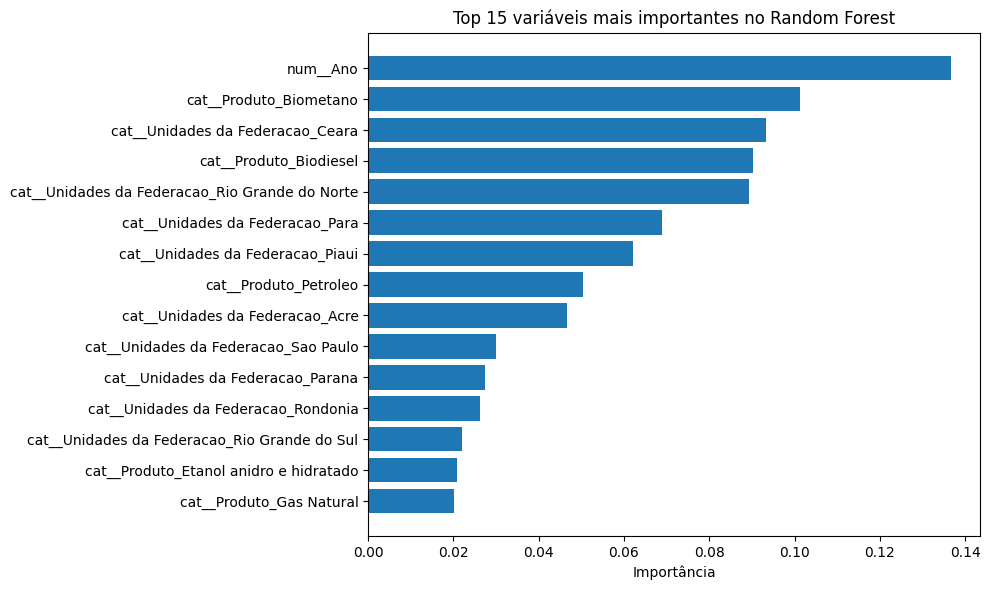

In [76]:
top15 = feature_importance.head(15)

plt.figure(figsize=(10, 6))
plt.barh(
    top15["Variável"][::-1],
    top15["Importância"][::-1]
)
plt.xlabel("Importância")
plt.title("Top 15 variáveis mais importantes no Random Forest")
plt.tight_layout()
plt.show()

> Os resultados da análise da importância das variáveis indicaram que o **'Ano' foi o atributo de maior contribuição para as previsões**, evidenciando a relevância do comportamento temporal da produção energética.

> O grande destaque de Biometano (Produto), Biodiesel(Produto), Ceará (UF) e Rio Grande do Norte (UF) sugerem que **tanto o tipo de produto quanto a localização geográfica exercem influência significativa** sobre a produção energética.

> Por outro lado, a variável **'Tipo' (fóssil/renovável) apresentou baixa importância relativa**. Esse comportamento pode ser explicado pelo fato de essa informação já estar implicitamente representada pela variável "Produto", tornando sua contribuição adicional reduzida para o processo de decisão do modelo.

## 9.4 Discussão da otimização

Após a otmização observou-se uma **melhora discreta** com relação aos resultados do Random Forest.

> Pode-se compreender que a **principal limitação** do banco de dados analisado **não está nos hiperparâmetros**, mas quantidade de atributos disponíveis e na ausência de importantes dados externos que podem ter grande impacto nos valores históricos relativos à produção energética.

> Também é necessário considerar que a utilização do TimeSeriesSplit, com ituido de considerar a série temporal, ainda esbarra na limitação de distinguir as diferentes séries contidas no dataset. Isso pode inflar o score da validação cruzada.

Hoje o modelo tenta prever a produção utilizando apenas:

* Ano;
* Unidade da Federação;
* Produto;
* Tipo de energia.

Na prática, a produção energética depende fortemente de dados externos, como:

* Preço internacional do petróleo;
* Demanda por combustíveis;
* Políticas públicas;
* Investimentos em infraestrutura;
* Condições econômicas;
* Evolução tecnológica;
* Aspectos regulatórios.

> Para otimização dos resultados das projeções para a Produção Energética é fundamental que estes dados externos (não contidos no relatório anual da ANP) sejam incluídos e considerados nos modelos testados.

# 10. Avaliação final no conjunto de teste

In [98]:
# Random Forest inicial
mae_rf = resultado_rf["MAE"]
rmse_rf = resultado_rf["RMSE"]
r2_rf = resultado_rf["R²"]

In [96]:
# Random Forest otimizado
mae_rf_otimizado = mae
rmse_rf_otimizado = rmse
r2_rf_otimizado = r2

In [97]:
# Tabela de comparação
comparacao_rf = pd.DataFrame({
    "Métrica": ["MAE", "RMSE", "R²"],
    "Random Forest (Inicial)": [
        mae_rf,
        rmse_rf,
        r2_rf
    ],
    "Random Forest (Otimizado)": [
        mae_rf_otimizado,
        rmse_rf_otimizado,
        r2_rf_otimizado
    ]
})

comparacao_rf

,Métrica,Random Forest (Inicial),Random Forest (Otimizado)
0,MAE,9.256760e+06,9.310159e+06
1,RMSE,5.318379e+07,5.302650e+07
2,R²,1.038155e-01,1.091083e-01


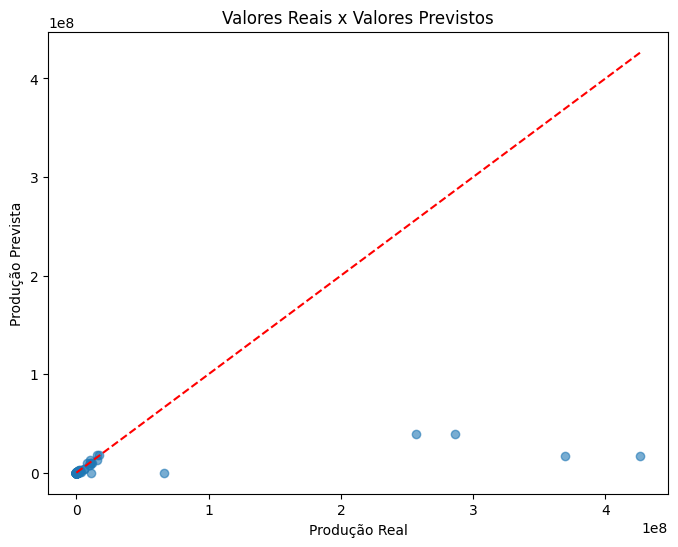

In [100]:
plt.figure(figsize=(8,6))

plt.scatter(y_real, y_pred, alpha=0.6)

plt.plot(
    [y_real.min(), y_real.max()],
    [y_real.min(), y_real.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Produção Real")
plt.ylabel("Produção Prevista")
plt.title("Valores Reais x Valores Previstos")

plt.show()

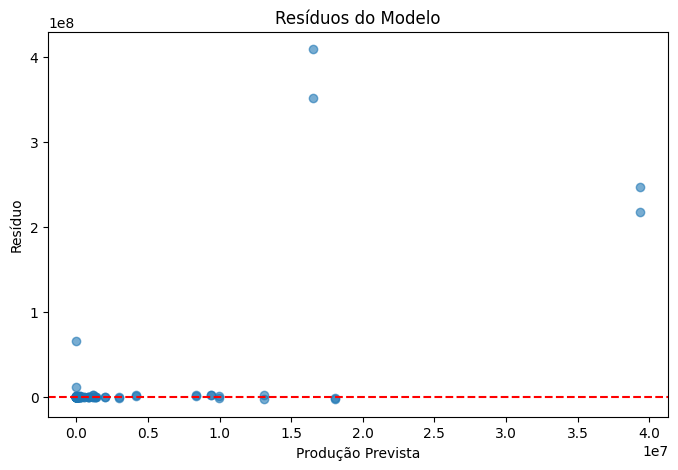

In [101]:
residuos = y_real - y_pred

plt.figure(figsize=(8,5))

plt.scatter(y_pred, residuos, alpha=0.6)

plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Produção Prevista")
plt.ylabel("Resíduo")

plt.title("Resíduos do Modelo")

plt.show()

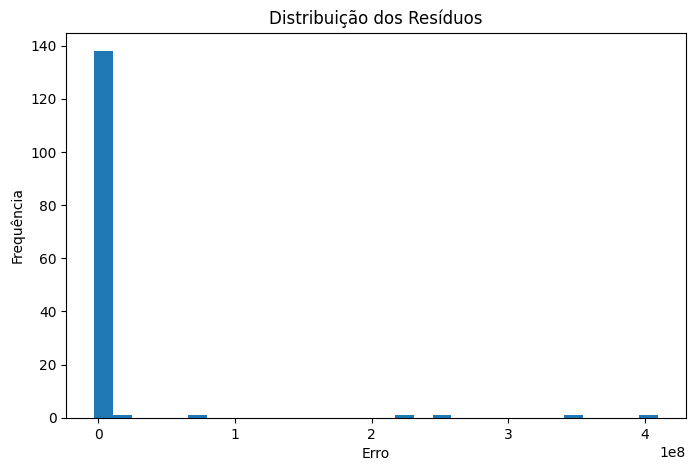

In [106]:
plt.figure(figsize=(8,5))

plt.hist(
    residuos,
    bins=30
)

plt.title("Distribuição dos Resíduos")

plt.xlabel("Erro")

plt.ylabel("Frequência")

plt.show()

> O modelo foi capaz de representar adequadamente a maior parte das observações presentes no conjunto de teste. Entretanto, verificou-se uma **tendência de subestimar registros com produção extremamente elevada.** É possível perceber esta tendência por meio dos pontos abaixo da linha de referência no gráfico de **'Valores Reais X Valores Previstos'**.

> A análise dos resíduos reforça esse entendimento, pois a maioria dos erros permanece próxima de zero, enquanto um pequeno conjunto de observações apresenta resíduos significativamente maiores. Esse resultado é consistente com a **elevada assimetria da variável alvo** identificada durante a análise exploratória, onde há a presença de alguns valores extremamente elevados em comparação à maior parte da distribuição.

Os gráficos sugerem que o Random Forest conseguiu capturar satisfatoriamente os padrões predominantes da base de dados, embora ainda apresente **limitações para representar adequadamente valores extremos de Produção Energética.**

# 11. Comparação final dos modelos

> **Regressão Linear**

In [114]:
# Regressão Linear

inicio = time.time()

modelo_lr, resultado_lr = avaliar_modelo(
    "Regressão Linear",
    LinearRegression(),
    X_train,
    X_test,
    y_train,
    y_test
)

tempo_lr = time.time() - inicio

> **Random Forest**

In [115]:
# Random Forest

inicio = time.time()

modelo_rf, resultado_rf = avaliar_modelo(
    "Random Forest",
    RandomForestRegressor(random_state=SEED),
    X_train,
    X_test,
    y_train,
    y_test
)

tempo_rf = time.time() - inicio



> **Gradient Boosting**

In [117]:
# Gradient Boosting

inicio = time.time()

modelo_gb, resultado_gb = avaliar_modelo(
    "Gradient Boosting",
    GradientBoostingRegressor(
        random_state=SEED
    ),
    X_train,
    X_test,
    y_train,
    y_test
)


tempo_gb = time.time() - inicio

> **Random Forest Otimizado**

In [119]:
# GridSearchCV
inicio = time.time()

tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=param_grid,
    cv=tscv,
    scoring="r2",
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

# Tempo total da otimização
tempo_grid = time.time() - inicio

Fitting 5 folds for each of 81 candidates, totalling 405 fits


In [120]:
resumo_modelos = pd.DataFrame({
    "Modelo": [
        "Regressão Linear",
        "Random Forest",
        "Gradient Boosting",
        "Random Forest Otimizado"
    ],

    "R²": [
        resultado_lr["R²"],
        resultado_rf["R²"],
        resultado_gb["R²"],
        r2
    ],

    "MAE": [
        resultado_lr["MAE"],
        resultado_rf["MAE"],
        resultado_gb["MAE"],
        mae
    ],

    "RMSE": [
        resultado_lr["RMSE"],
        resultado_rf["RMSE"],
        resultado_gb["RMSE"],
        rmse
    ],

    "Tempo de treino (s)": [
        tempo_lr,
        tempo_rf,
        tempo_gb,
        tempo_grid
    ],

    "Observações": [
        "Modelo baseline.",
        "Melhor desempenho inicial.",
        "Desempenho semelhante ao baseline.",
        "Modelo final após GridSearchCV."
    ]
})

resumo_modelos

,Modelo,R²,MAE,RMSE,Tempo de treino (s),Observações
0,Regressão Linear,-0.037482,1.078452e+07,5.722304e+07,0.159623,Modelo baseline.
1,Random Forest,0.103815,9.256760e+06,5.318379e+07,0.415575,Melhor desempenho inicial.
2,Gradient Boosting,-0.036755,1.064066e+07,5.720298e+07,0.122575,Desempenho semelhante ao baseline.
3,Random Forest Otimizado,0.109108,9.310159e+06,5.302650e+07,158.051427,Modelo final após GridSearchCV.


# 12. Boas práticas e rastreabilidade

#### **Ambiente de execução:**
Google Colab (CPU)

#### **Seed utilizada:**
42

#### **Principais decisões de pré-processamento:**
* **Remoção** das colunas Index e Unidade, por não agregarem informação preditiva ao modelo.
* **Inclusão** da variável Região, derivada da Unidade da Federação, para enriquecer a análise exploratória (mantida apenas para análise e não utilizada na modelagem final).
* Aplicação do **One-Hot Encoding** nas variáveis categóricas.
* Utilização da **transformação log1p()** na variável alvo devido à elevada assimetria da distribuição da produção energética.
* **Separação** cronológica dos conjuntos de **treinamento** (2014–2021) e **teste** (2022–2023), preservando a ordem temporal.

#### **Modelos avaliados:**
* Regressão Linear
* Random Forest Regressor
* Gradient Boosting Regressor

#### **Limitações conhecidas:**
* Base composta por apenas 720 registros.
* Apenas dez anos históricos (2014–2023).
* Ausência de variáveis econômicas e setoriais relevantes.
* Elevada assimetria da variável Produção.
* Presença de diversos valores iguais a zero.
* O Random Forest apresentou limitações para extrapolar tendências temporais além do intervalo observado.

#### **Abordagens avaliadas e descartadas:**
* Conversão de todas as unidades físicas (m³, barris etc.) para uma única unidade — descartada por representar produtos energeticamente distintos.
* Projeções para 2024–2028 utilizando Random Forest — descartadas após constatar que o algoritmo não extrapola tendências temporais de forma adequada.
* Utilização de Deep Learning — descartada devido ao reduzido tamanho da base de dados e à baixa dimensionalidade do problema.

#### **Registro de decisões:**

| Decisão                                            | Justificativa                                                                           | Impacto esperado                                   |
| -------------------------------------------------- | --------------------------------------------------------------------------------------- | -------------------------------------------------- |
| Remover as colunas `index` e `Unidade`             | Não continham informação preditiva relevante                                            | Redução de ruído e simplificação da modelagem      |
| Utilizar One-Hot Encoding                          | Permitir que algoritmos de regressão tratassem variáveis categóricas                    | Representação adequada das categorias              |
| Aplicar `log1p()` na variável Produção             | Corrigir elevada assimetria e reduzir influência dos valores extremos                   | Melhor estabilidade do treinamento                 |
| Manter divisão cronológica entre treino e teste    | Preservar a ordem temporal dos dados                                                    | Evitar vazamento de informação                     |
| Utilizar TimeSeriesSplit no GridSearchCV           | Respeitar a natureza temporal da base durante a validação cruzada                       | Avaliação mais realista do modelo                  |
| Comparar três algoritmos distintos                 | Identificar o modelo mais adequado ao problema                                          | Seleção baseada em evidências                      |
| Selecionar o Random Forest para otimização         | Melhor desempenho entre os modelos candidatos                                           | Aumento potencial da capacidade preditiva          |
| Otimizar hiperparâmetros com GridSearchCV          | Buscar a melhor configuração do Random Forest                                           | Pequena melhoria nas métricas do modelo            |
| Utilizar MAE, RMSE e R² como métricas de avaliação | Avaliar diferentes aspectos do desempenho da regressão                                  | Comparação mais robusta entre modelos              |
| Analisar a importância das variáveis               | Interpretar quais atributos mais influenciaram as previsões                             | Maior interpretabilidade do modelo                 |
| Não utilizar projeções para 2024–2028              | O Random Forest demonstrou limitações para extrapolar valores fora do período observado | Preservação da consistência metodológica do estudo |


# 13. Conclusão

> O presente MVP teve como objetivo **comparar diferentes algoritmos de Machine Learning** aplicados à estimativa da produção energética brasileira, utilizando dados históricos disponibilizados pela Agência Nacional do Petróleo, Gás Natural e Biocombustíveis (ANP). Para isso, foram conduzidas todas as etapas de um projeto de Ciência de Dados, incluindo **análise exploratória, preparação dos dados, construção de pipelines, treinamento, comparação de modelos, otimização de hiperparâmetros e avaliação final**.

> A análise exploratória permitiu **compreender as principais características da base de dados**, identificando os **valores faltantes**, a **elevada assimetria da variável alvo** e a existência de **valores extremos**. Essas observações fundamentaram decisões importantes durante o pré-processamento, como a aplicação da **transformação logarítmica** na variável de produção e a utilização de codificação **One-Hot Encoding** para as variáveis categóricas.

> Foram avaliados três algoritmos de regressão supervisionada: **Regressão Linear, Random Forest Regressor e Gradient Boosting Regressor**. Entre os modelos analisados, o **Random Forest apresentou o melhor desempenho**, obtendo os menores valores de MAE e RMSE e o maior coeficiente de determinação (R²). Posteriormente, esse modelo foi submetido à **otimização de hiperparâmetros utilizando GridSearchCV em conjunto com TimeSeriesSplit**, resultando em uma pequena melhora nas métricas obtidas no conjunto de teste.

> A análise dos resíduos e da importância das variáveis permitiu compreender melhor o comportamento do modelo. Verificou-se que **atributos como o ano de referência, o produto energético e a unidade da federação exerceram maior influência nas previsões**, enquanto a variável referente ao tipo de energia apresentou contribuição reduzida. Também foi observado que o modelo apresentou maior dificuldade em estimar produções extremamente elevadas, comportamento compatível com a elevada dispersão identificada na variável alvo durante a análise exploratória.

> Embora o Random Forest tenha apresentado o melhor desempenho entre os modelos avaliados, os resultados obtidos indicam que a **capacidade preditiva permaneceu limitada**. Esse comportamento sugere que **a produção energética brasileira depende significativamente de fatores que não estão representados no conjunto de dados utilizado**, como indicadores econômicos, políticas públicas, demanda por combustíveis, investimentos em infraestrutura e outros aspectos do setor energético. Dessa forma, a principal limitação do estudo está relacionada à disponibilidade de atributos explicativos, e não necessariamente aos algoritmos empregados.

> Durante o desenvolvimento do trabalho também **foi avaliada a possibilidade de utilizar o modelo otimizado para realizar projeções futuras da produção energética**. Entretanto, optou-se por não incluir essa etapa na versão final do MVP, uma vez que foi c**onstatado que o Random Forest apresenta limitações para extrapolar tendências temporais além do intervalo observado**, produzindo previsões pouco representativas para anos não contemplados na base histórica. Essa decisão buscou preservar a consistência metodológica do estudo e **garantir que as conclusões apresentadas fossem compatíveis com as capacidades do modelo utilizado**.

> Para trabalhos futuros, recomenda-se o processo de **Feature engineering**, considerando variáveis econômicas, demográficas e setoriais que possam explicar melhor a produção energética brasileira, bem como a avaliação de algoritmos específicos para séries temporais quando o objetivo for realizar projeções para períodos futuros.

> De forma geral, **os objetivos propostos para este MVP foram atingidos**. O trabalho permitiu comparar diferentes técnicas de regressão supervisionada, identificar o modelo de melhor desempenho para o conjunto de dados analisado e discutir, de forma fundamentada, tanto seu potencial quanto suas limitações, reforçando a importância da qualidade e da representatividade dos dados para o sucesso de projetos de Machine Learning.